In [2]:
# import required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv("housing 1.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# `Data Understanding` 

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
data.describe()  # 5 stats summary

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [13]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [15]:
data.duplicated().sum()  # data does not contain any duplicate observation -> 0

np.int64(0)

######     Missing value

In [16]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [17]:
(data.isna().sum() / len(data)) * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

# Handling missing values

        Finding outlier
        Univariate Analysis ---> Box Plot

In [18]:
# plt.figure()
# plt.boxplot(data["total_bedrooms"])
# plt.title("Total Bedroom Box Plot")
# plt.show()

In [19]:
data["total_bedrooms"]

0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [20]:
data["total_bedrooms"].mean()

np.float64(537.8705525375618)

In [21]:
data["total_bedrooms"].median()  


435.0

In [22]:
# mean and median different --> outlier present

filling missing value

In [23]:
# np.median(data["total_bedrooms"])
data["total_bedrooms"].median()

435.0

In [24]:
# data.fillna({"total_bedroom" : np.median(data["total_bedrooms"])})

In [25]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())
data["total_bedrooms"]

0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

     Unvariate Analysis
         Box Plot / Whisker Plot --> Outlier Detection
         Histogram --> Data Distribution

In [26]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

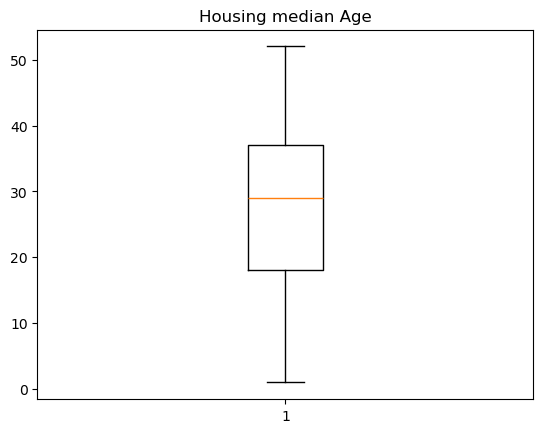

In [27]:
plt.figure()
plt.boxplot(data["housing_median_age"])
plt.title("Housing median Age")
plt.show()

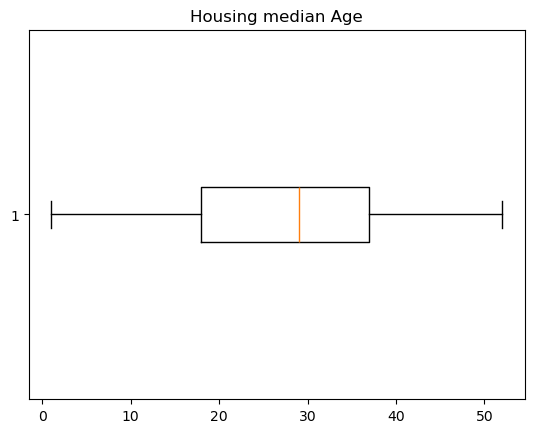

In [28]:
plt.figure()
plt.boxplot(data["housing_median_age"] , orientation = "horizontal")
plt.title("Housing median Age")
plt.show()

In [29]:
data["median_house_value"].mean() , data["median_house_value"].median()

(np.float64(206855.81690891474), 179700.0)

In [30]:
numerical_data = data.select_dtypes(["int" , "float"])
numerical_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


    Outlier detection

longitude


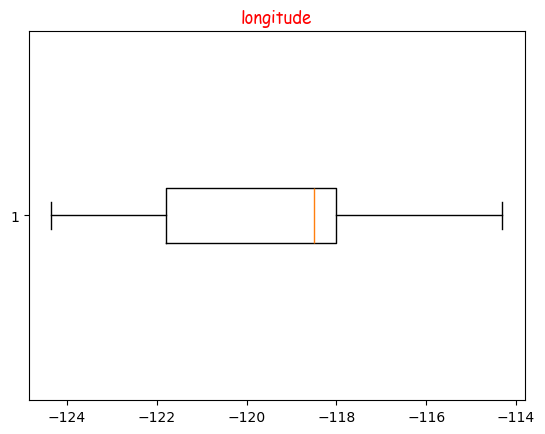


--------------------
latitude


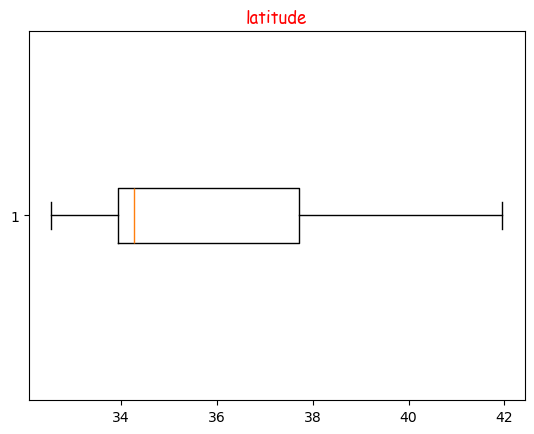


--------------------
housing_median_age


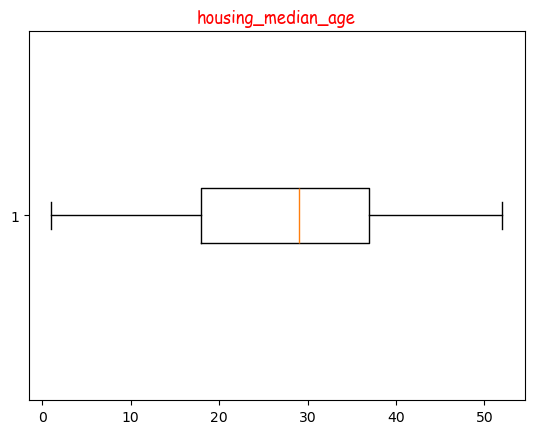


--------------------
total_rooms


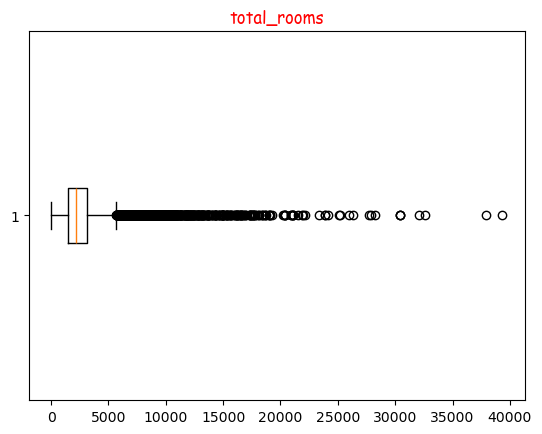


--------------------
total_bedrooms


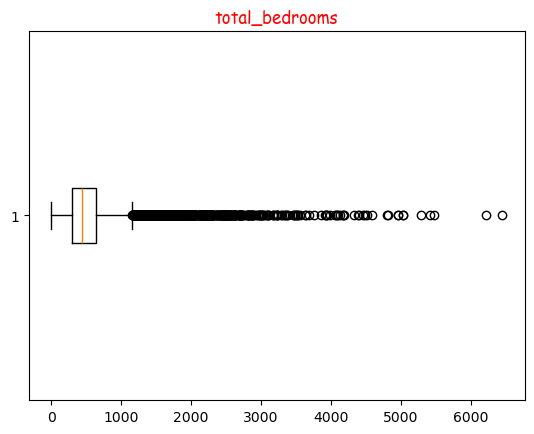


--------------------
population


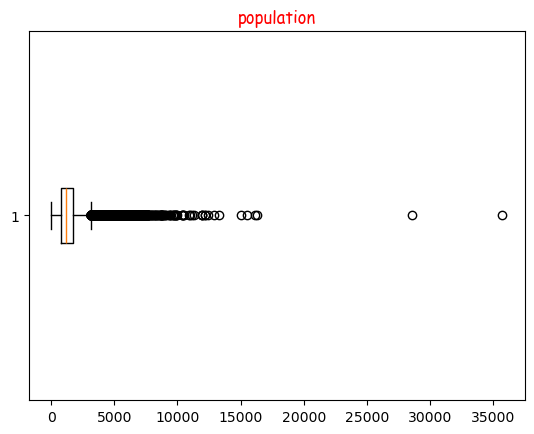


--------------------
households


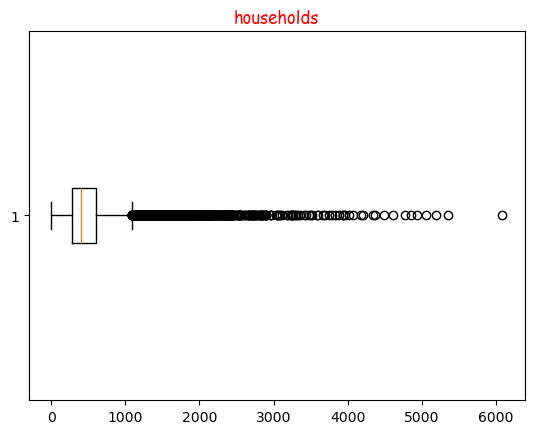


--------------------
median_income


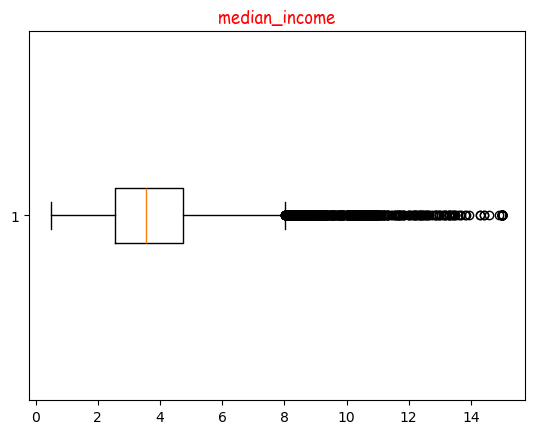


--------------------
median_house_value


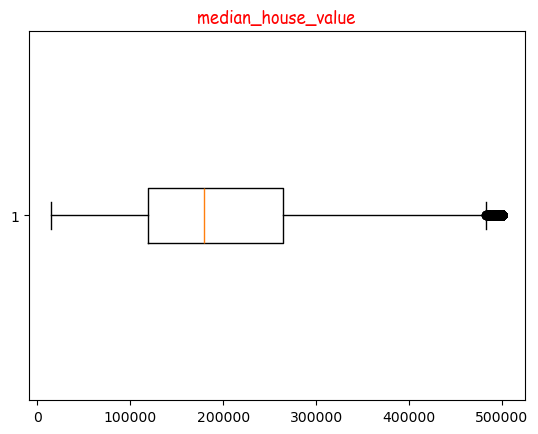


--------------------


In [31]:
for i in numerical_data:
    print(i)
    plt.figure()
    plt.boxplot(numerical_data[i] , orientation = "horizontal")
    plt.title(i , color = "red" , fontfamily = "cursive")
    plt.show()
    print()
    print("--" * 10)

In [37]:
# Otlier in total_room , total_bedroom , population , household etc.

    Histogram

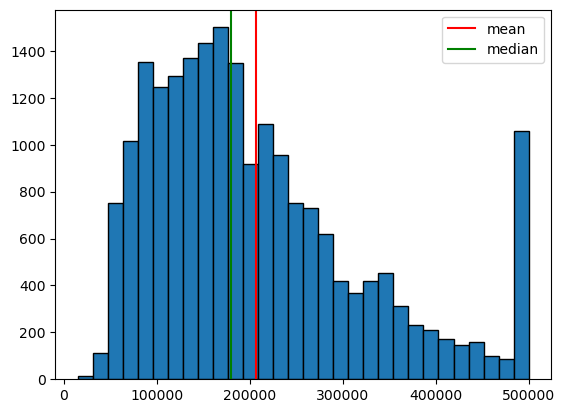

In [34]:
plt.figure()
plt.hist(data["median_house_value"] , bins = 30 , edgecolor = "black")
plt.axvline(np.mean(data["median_house_value"]) , color = "red" , label = "mean")
plt.axvline(np.median(data["median_house_value"]) , color = "green" , label = "median")

plt.legend()
plt.show()

longitude


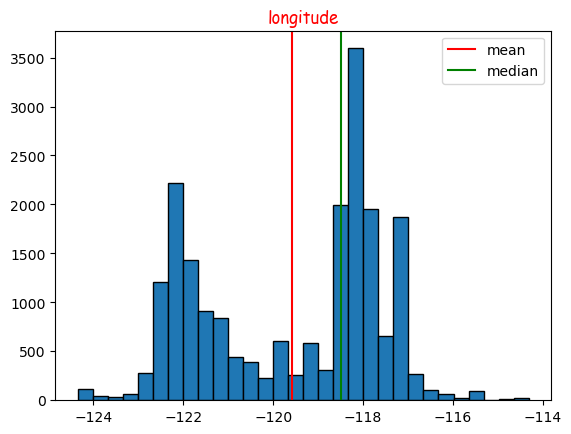


--------------------
latitude


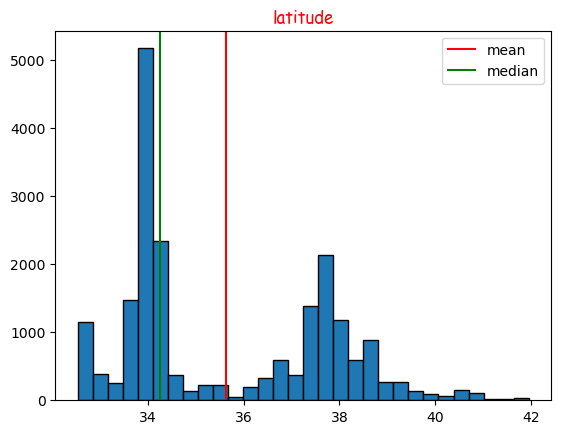


--------------------
housing_median_age


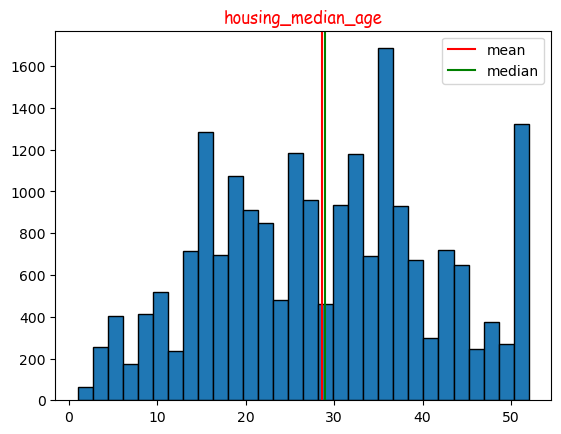


--------------------
total_rooms


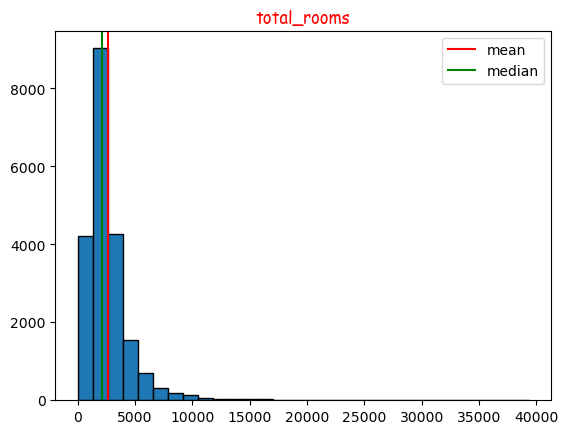


--------------------
total_bedrooms


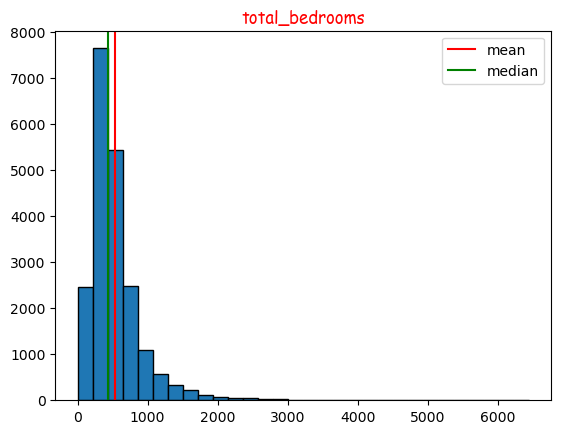


--------------------
population


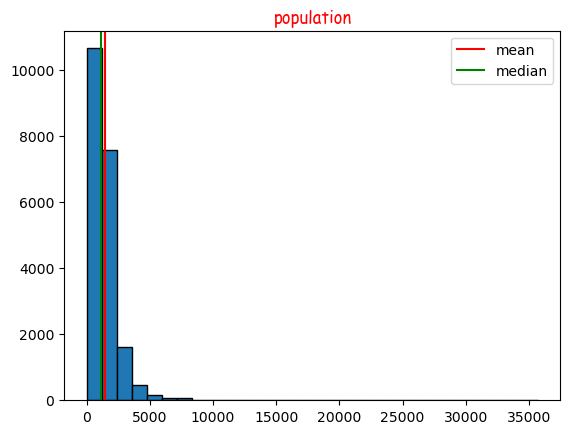


--------------------
households


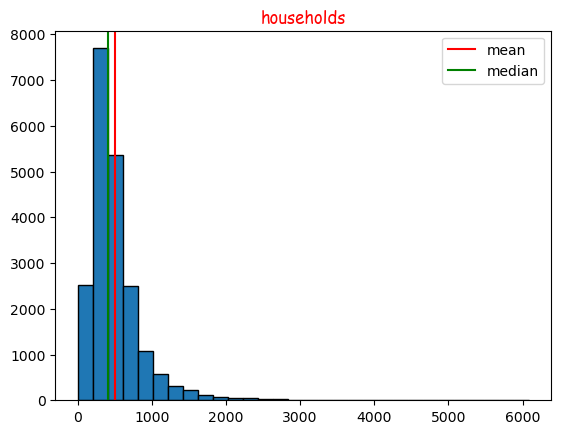


--------------------
median_income


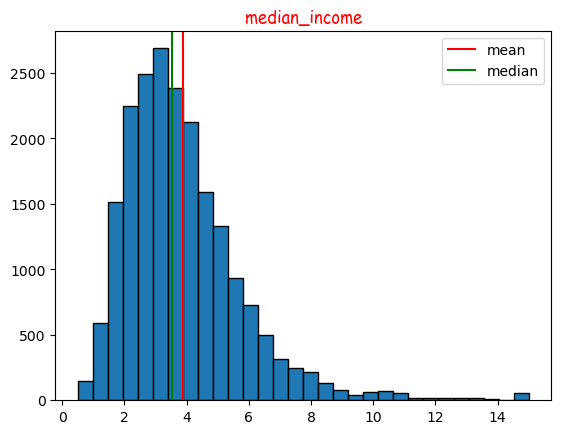


--------------------
median_house_value


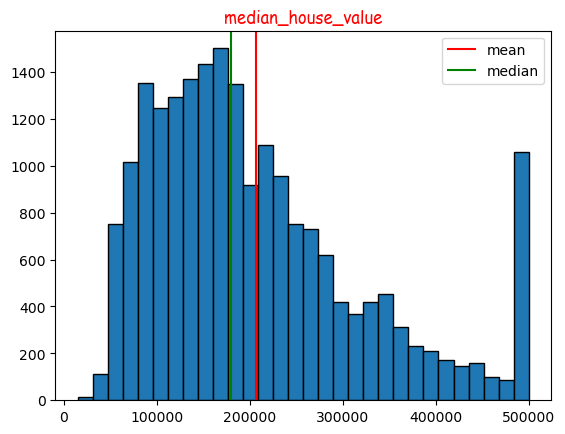


--------------------


In [35]:
for i in numerical_data:
    print(i)
    plt.figure()
    plt.hist(numerical_data[i] , bins = 30 , edgecolor = "k")
    plt.axvline(np.mean(numerical_data[i]) , color = "red" , label = "mean")
    plt.axvline(np.median(numerical_data[i]) , color = "green" , label = "median")
    plt.title(i , color = "red" , fontfamily = "cursive")
    plt.legend()
    plt.show()
    print()
    print("--" * 10)

In [36]:
data["ocean_proximity"]

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

In [37]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [38]:
data["ocean_proximity"].value_counts().index

Index(['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'], dtype='object', name='ocean_proximity')

In [39]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

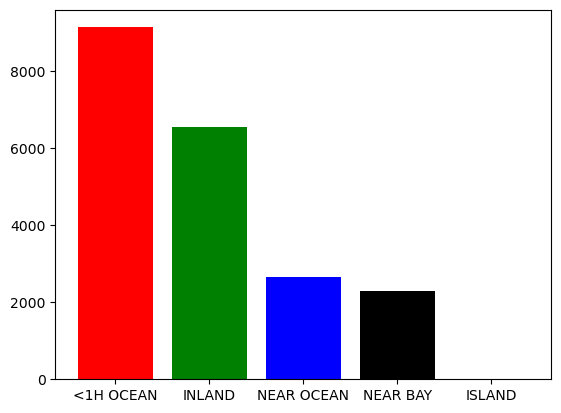

In [40]:
plt.figure()
plt.bar(data["ocean_proximity"].value_counts().index , data["ocean_proximity"].value_counts() , color = ["r" , "g" , "b" , "k" , "y"])
plt.show()

<Axes: xlabel='ocean_proximity', ylabel='count'>

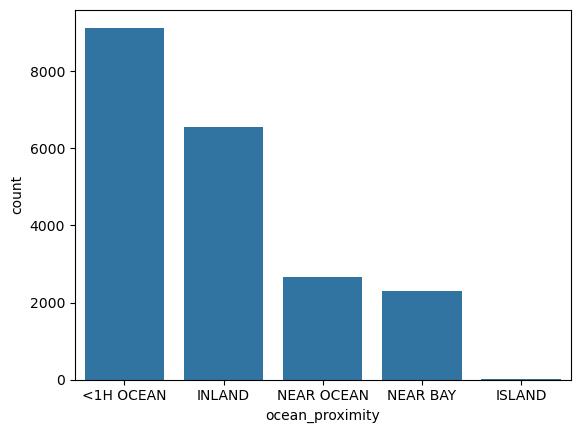

In [56]:
sns.barplot(data["ocean_proximity"].value_counts())

<Axes: xlabel='median_house_value', ylabel='Count'>

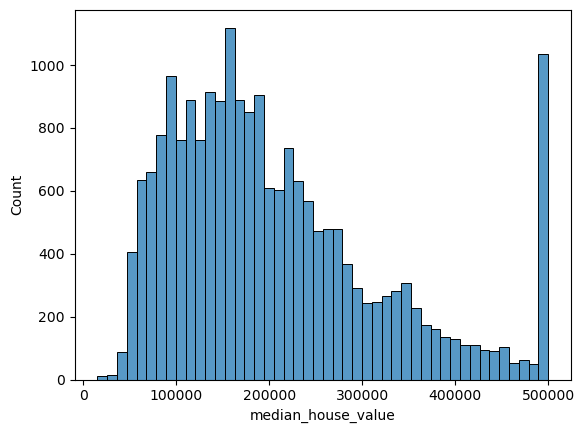

In [59]:
sns.histplot(data["median_house_value"])

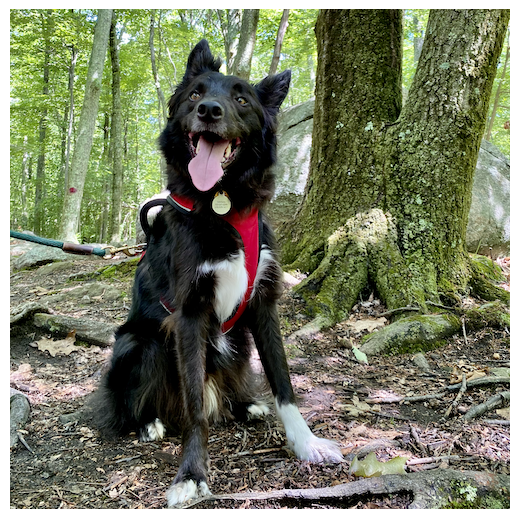

In [60]:
sns.dogplot(["median_house_value"])

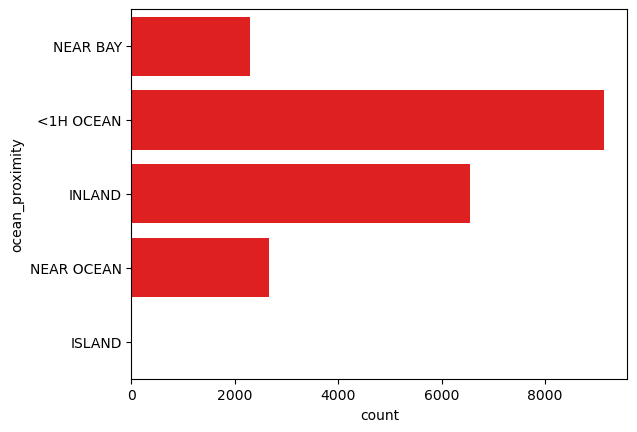

In [43]:
plt.figure()
sns.countplot(data["ocean_proximity"] , color = "r")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_5136\3705365859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data["ocean_proximity"] , palette = ["r" , "g" , "b" , "k" , "y"])


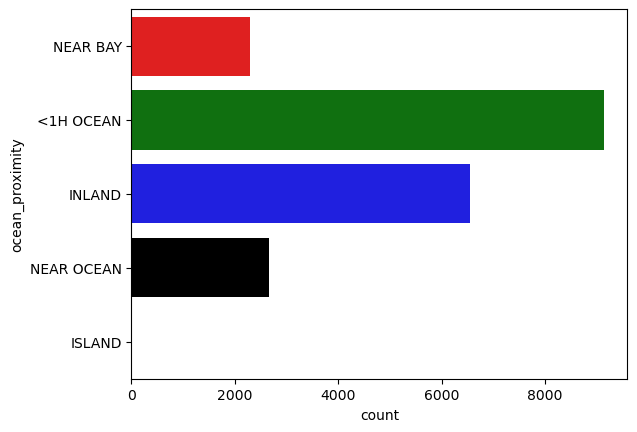

In [44]:
plt.figure()
sns.countplot(data["ocean_proximity"] , palette = ["r" , "g" , "b" , "k" , "y"])
plt.show()

In [46]:
a = [10,20,30,40]
labels = ["a","b","c","d"]

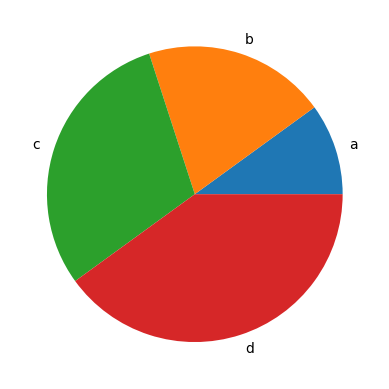

In [47]:
plt.figure()
plt.pie(x = a , labels = labels)
plt.show()

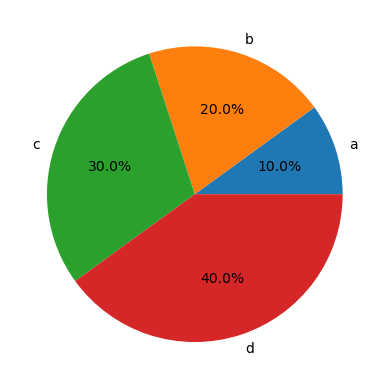

In [49]:
plt.figure()
plt.pie(x = a , labels = labels , autopct = '%1.1f%%')
plt.show()

In [55]:
data["ocean_proximity"]

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

In [52]:
data["ocean_proximity"].value_counts().index

Index(['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'], dtype='object', name='ocean_proximity')

In [54]:
data["ocean_proximity"].value_counts().values

array([9136, 6551, 2658, 2290,    5])

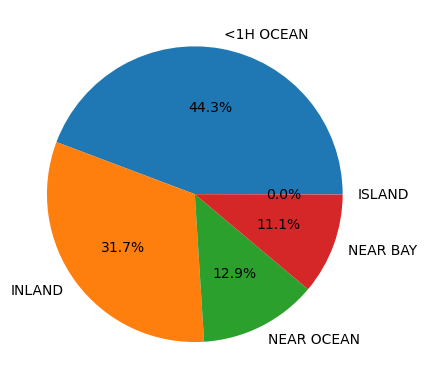

In [63]:
plt.figure()
plt.pie(data["ocean_proximity"].value_counts()  , labels = data["ocean_proximity"].value_counts().index , autopct = "%1.1f%%" )
plt.show()

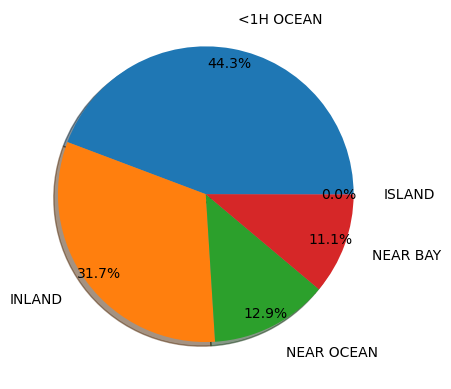

In [66]:
plt.figure()
plt.pie(data["ocean_proximity"].value_counts()  , labels = data["ocean_proximity"].value_counts().index , autopct = "%1.1f%%" , pctdistance = 0.9 , shadow = True , labeldistance = 1.2)
plt.show()

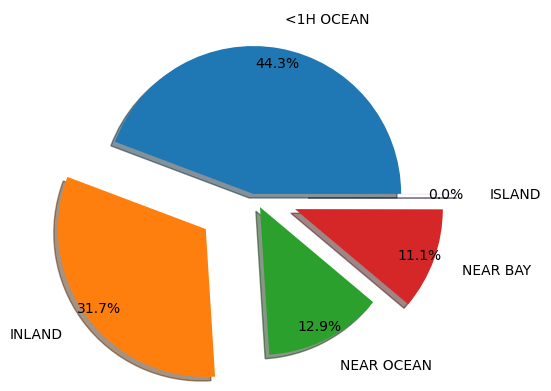

In [67]:
plt.figure()
plt.pie(data["ocean_proximity"].value_counts()  , labels = data["ocean_proximity"].value_counts().index , autopct = "%1.1f%%" , pctdistance = 0.9 , shadow = True , labeldistance = 1.2, explode = [0,0.4,0.1,0.3,0.4])
plt.show()

# Bivariate Analysis
    Scatter Plot
    Line Plot

In [68]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


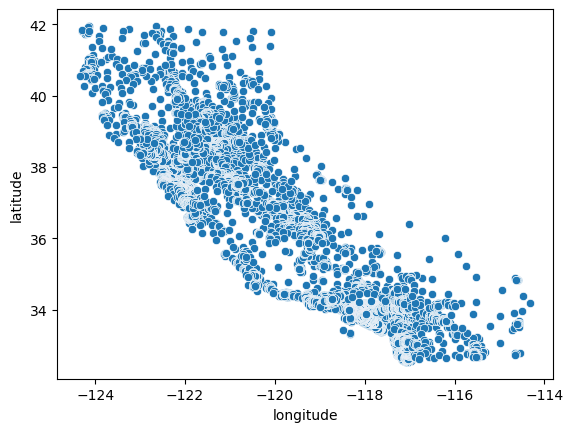

In [70]:
plt.figure()
sns.scatterplot(data = data , x = "longitude" , y = "latitude")
plt.show()

In [71]:
x = np.array([10,20,30,40,50])
y = np.array([100,200,300,400,500])
x,y

(array([10, 20, 30, 40, 50]), array([100, 200, 300, 400, 500]))

<Axes: >

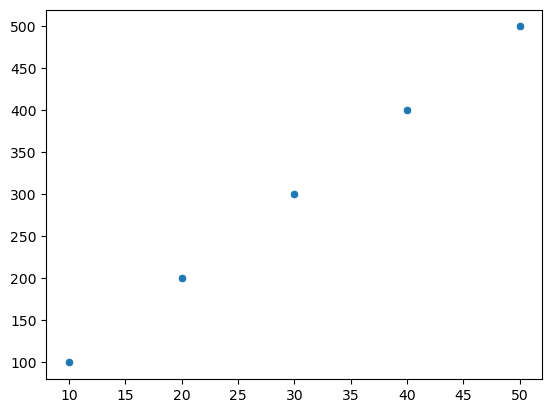

In [72]:
sns.scatterplot(x = x , y= y)

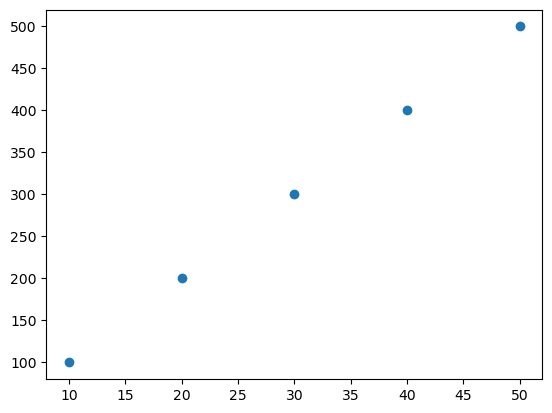

In [75]:
plt.figure()
plt.scatter(x,y)
plt.show()

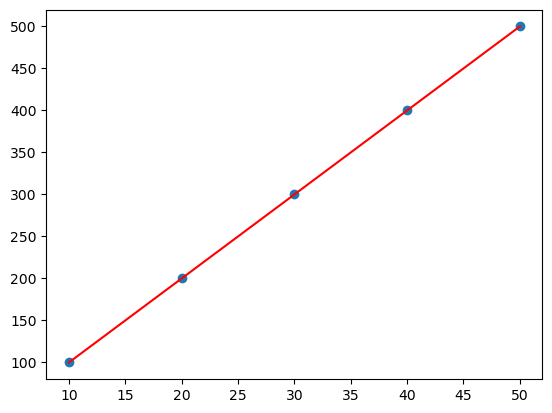

In [76]:
plt.figure()
plt.scatter(x,y)
plt.plot(x,y,color="r")
plt.show()

In [77]:
x

array([10, 20, 30, 40, 50])

In [79]:
y = np.array([500,400,300,200,100])
y

array([500, 400, 300, 200, 100])

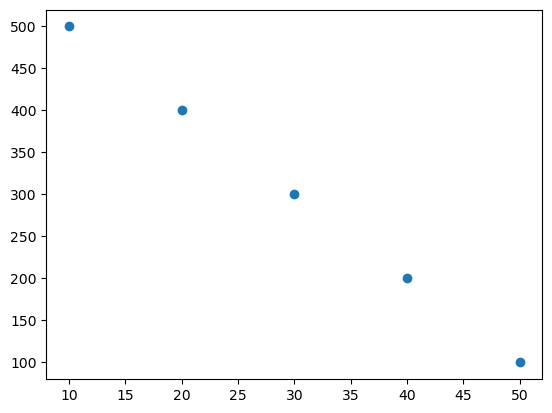

In [81]:
plt.scatter(x,y)
plt.show()

In [82]:
height = np.random.normal(170,15,100)
weight = 8.6 * height + np.random.random(100)*30

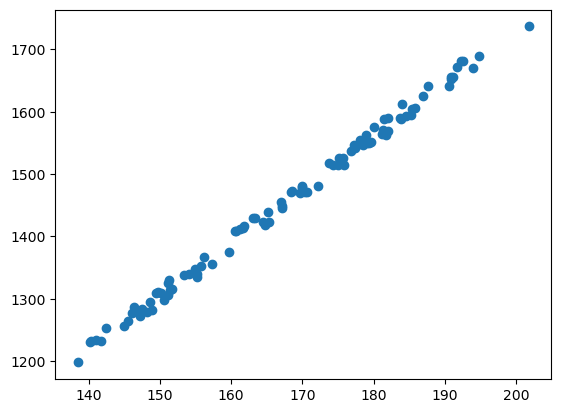

In [85]:
plt.scatter(height,weight)

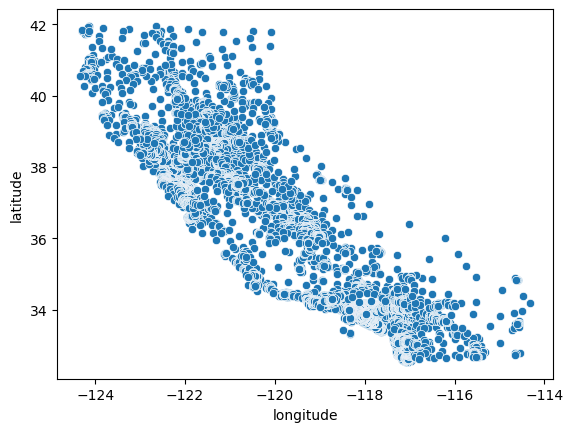

In [99]:
plt.figure()
sns.scatterplot(data = data,x = "longitude" , y = "latitude" )
plt.show()

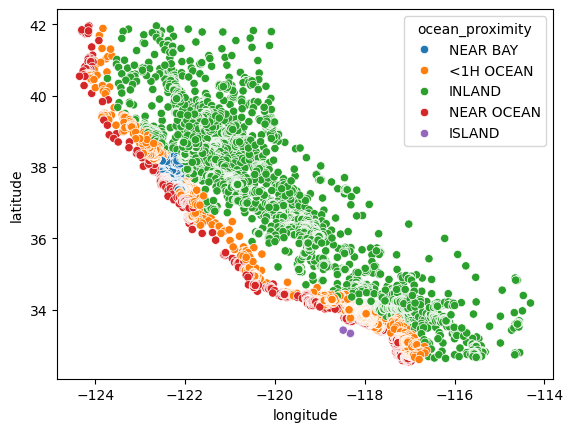

In [91]:
plt.figure()
sns.scatterplot(data = data,x = "longitude" , y = "latitude" , hue = "ocean_proximity")
plt.show()

In [95]:
new = sns.load_dataset("tips")
new

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

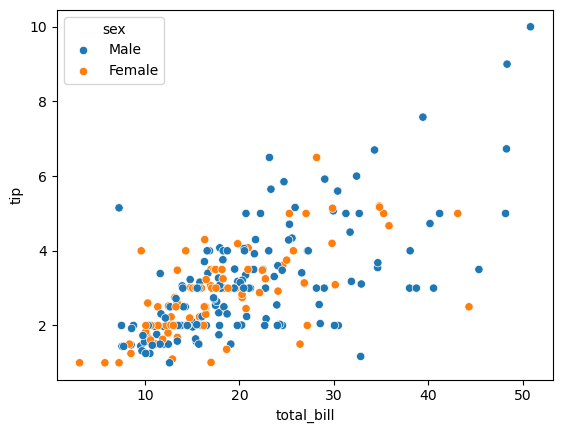

In [96]:
sns.scatterplot(data = new , x = "total_bill" , y = "tip" , hue = "sex") 

<Axes: xlabel='total_bill', ylabel='tip'>

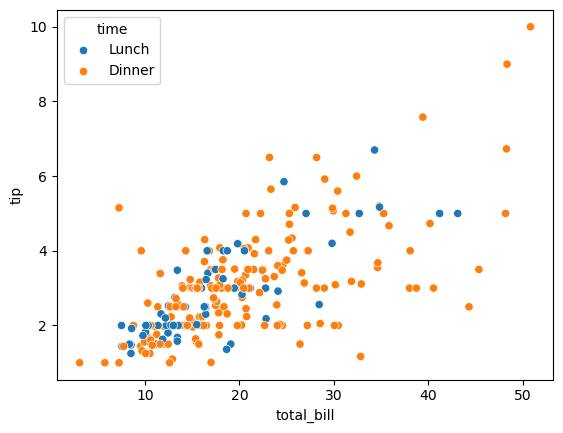

In [97]:
sns.scatterplot(data = new , x = "total_bill" , y = "tip" , hue = "time") 

<Axes: xlabel='total_bill', ylabel='tip'>

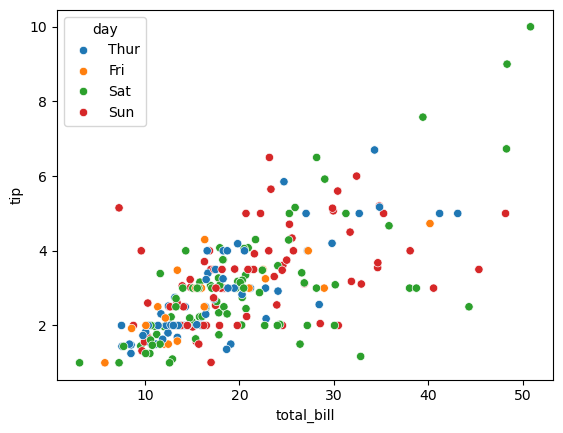

In [98]:
sns.scatterplot(data = new , x = "total_bill" , y = "tip" , hue = "day") 

In [100]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


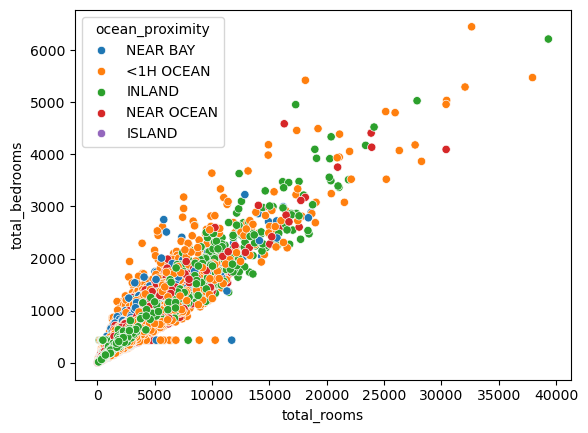

In [103]:
plt.figure()
sns.scatterplot(data = data , x = "total_rooms" , y = "total_bedrooms",hue = "ocean_proximity")
plt.show()

In [104]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

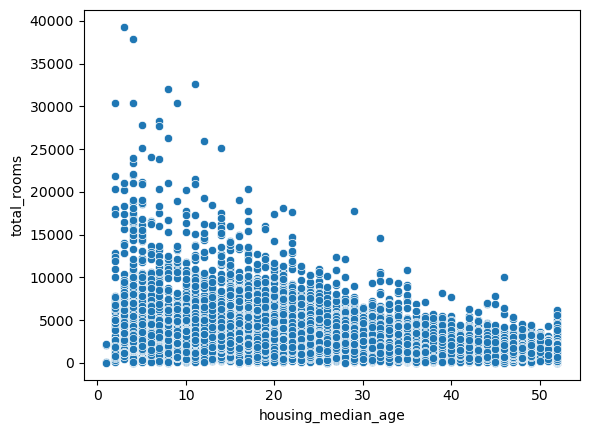

In [107]:
plt.figure()
sns.scatterplot(data = data , x = "housing_median_age" , y = "total_rooms")
plt.show()

# Multivariate Analysis

In [109]:
numerical_data = data.select_dtypes(["int" , "float"])
numerical_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


     Corr / pearson corr coeff
     Positive Relationship
     Negative Relationship

In [112]:
numerical_data.corr()    # longitude ka longitude k sath relationship , longitude ka lattitude k sath relationship(-0.9024) -> strong relationship , inverse ........

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000


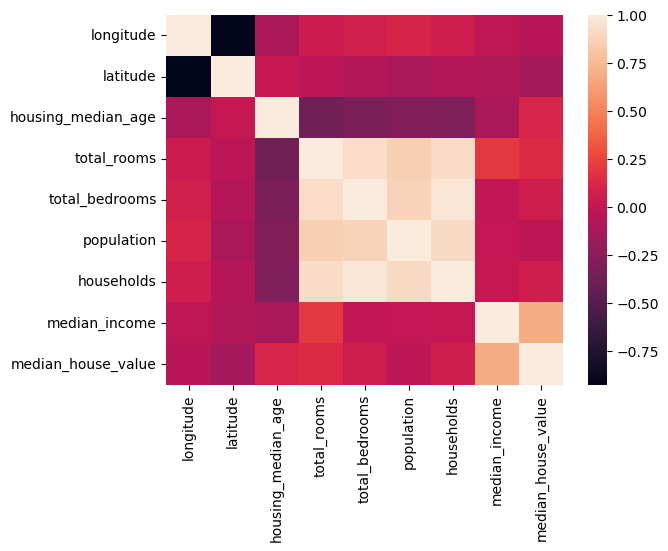

In [117]:
plt.figure()
sns.heatmap(numerical_data.corr())
plt.show()

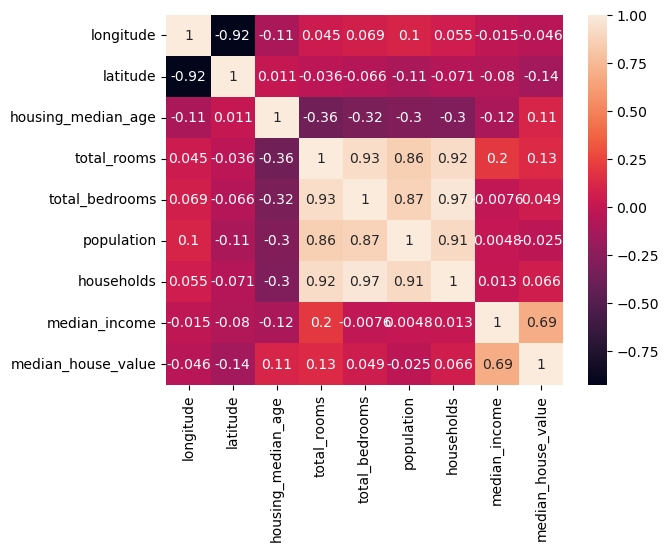

In [119]:
plt.figure()
sns.heatmap(numerical_data.corr(), annot = True)
plt.show()

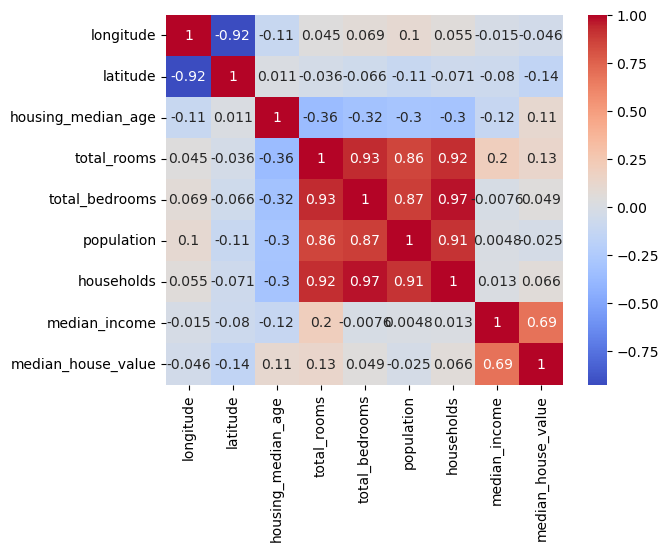

In [118]:
plt.figure()
sns.heatmap(numerical_data.corr(), annot = True , cmap = "coolwarm")
plt.show()

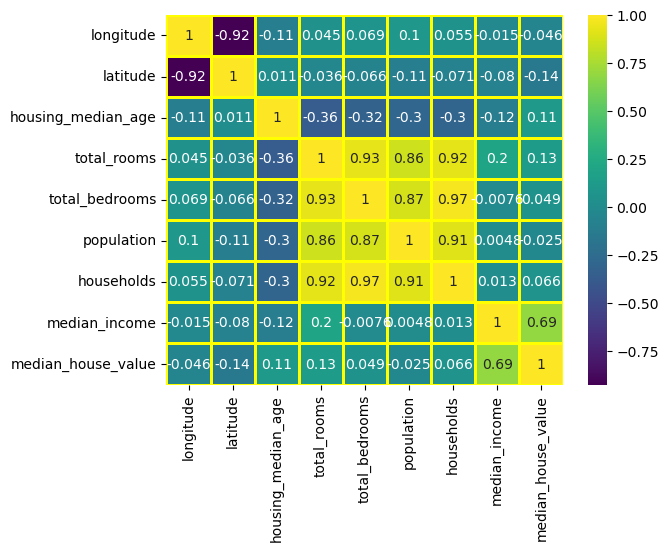

In [130]:
plt.figure()
sns.heatmap(numerical_data.corr(), annot = True , cmap = "viridis" , linecolor = "yellow" , linewidths = 1)
plt.show()

In [122]:
import plotly.express as px

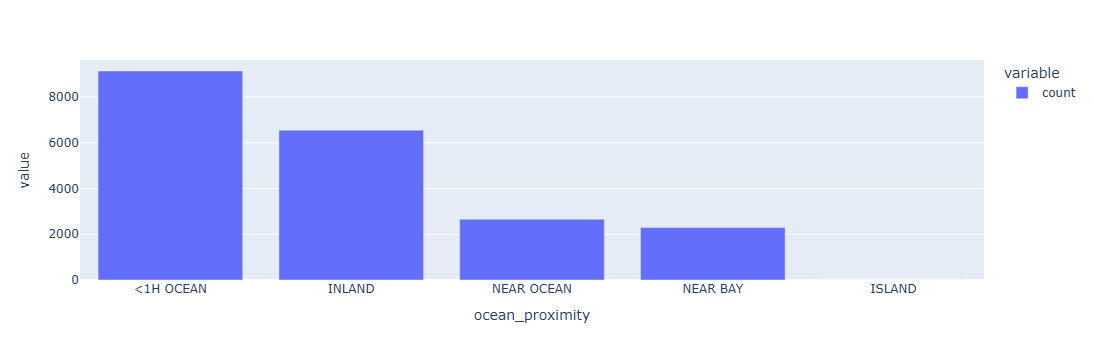

In [126]:
px.bar(data["ocean_proximity"].value_counts())

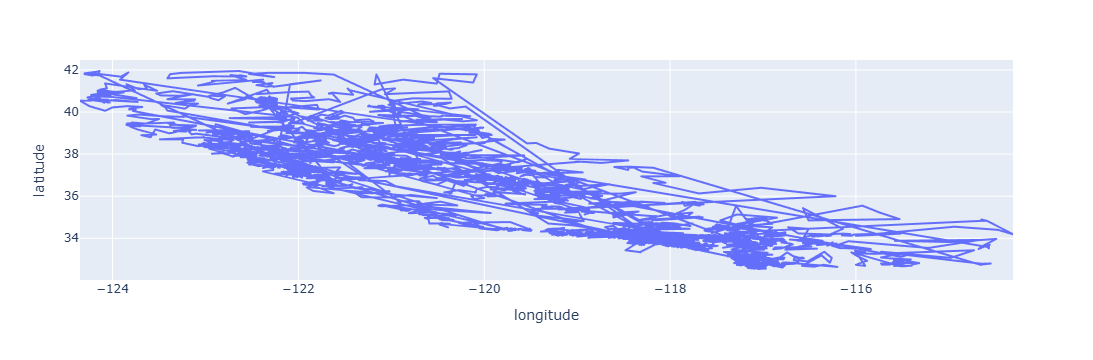

In [125]:
px.line(data_frame = data , x = "longitude" , y = "latitude")

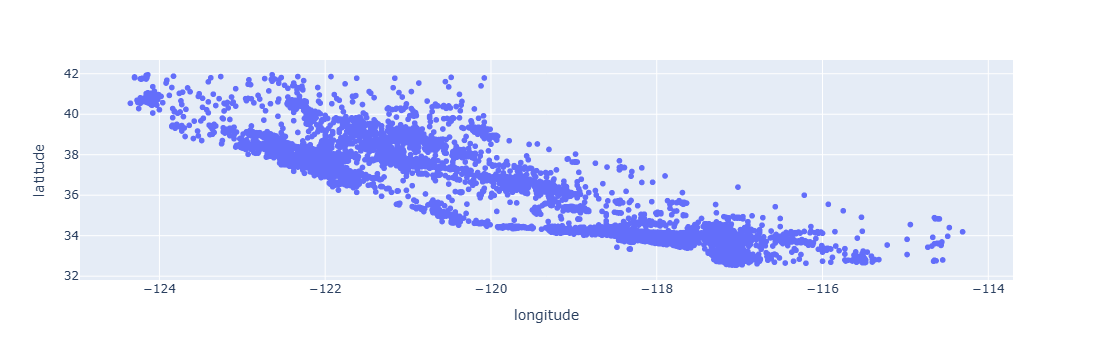

In [127]:
px.scatter(data_frame = data , x = "longitude" , y = "latitude")
